# Feature Importance and Non-Linear Correlation Analysis

This notebook explores the contribution of various features to house price prediction.
We go beyond standard Pearson correlation to identify non-linear relationships and model-based feature importance.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import kagglehub
warnings.filterwarnings('ignore')

from src.house_prices.dataloader import load_dataset
from src.house_prices.features import engineer_house_features as original_engineer_house_features
from src.house_prices.preprocessing import ( 
    target_encode, 
    one_hot_encode, 
    log_transform, 
    inverse_log_transform, 
    standardize
)

from sklearn.model_selection import train_test_split

print("Modules imported successfully.")

Modules imported successfully.


In [ ]:
# --- Step 1: Data Loading & Initial Cleaning ---
path = kagglehub.dataset_download("debayank2024/house-price-prediction")
df = load_dataset(path)

# Filter rows where bedrooms or bathrooms are 0.0
df = df[(df['bedrooms'] > 0.0) & (df['bathrooms'] > 0.0)].copy()

# Remove extreme price outliers (99th percentile)
outlier_quantile = 0.99
q = df['price'].quantile(outlier_quantile)
df = df[df['price'] <= q].copy()

print(f"Dataset loaded. Shape after cleaning: {df.shape}")

Loading dataset from: /home/mordicus/.cache/kagglehub/datasets/debayank2024/house-price-prediction/versions/1/modified_data.csv
Dataset loaded. Shape after cleaning: (4552, 18)


In [ ]:
# --- Step 2: Data Splitting ---
X = df.drop(columns=['price'])
y = df['price']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

X_train['date'] = pd.to_datetime(X_train['date'])
X_val['date'] = pd.to_datetime(X_val['date'])
X_test['date'] = pd.to_datetime(X_test['date'])

print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (3641, 17), Val shape: (455, 17), Test shape: (456, 17)


In [ ]:
# --- Step 3: Feature Engineering (Replicating Pipeline Logic) ---
min_date = X_train['date'].min()

# Pass 1: Base features
X_train = original_engineer_house_features(X_train, min_date=min_date, rare_types=None)

# Identify rare street types from training data
counts = X_train['street_type'].value_counts(normalize=True)
rare_types = counts[counts < 0.01].index.tolist()

# Pass 2: Apply to all sets
X_val = original_engineer_house_features(X_val, min_date=min_date, rare_types=rare_types)
X_test = original_engineer_house_features(X_test, min_date=min_date, rare_types=rare_types)

print(f"Rare street types identified: {rare_types}")

Rare street types identified: []


In [ ]:
# --- Step 4: Preprocessing ---
# Log transform target
y_train = np.log1p(y_train)
y_val = np.log1p(y_val)
y_test = np.log1p(y_test)

# Target encode cityzip
X_train, encoder_target = target_encode(X_train, 'cityzip', y_train)
X_val, _ = target_encode(X_val, 'cityzip', y_train, encoder=encoder_target)
X_test, _ = target_encode(X_test, 'cityzip', y_train, encoder=encoder_target)

X_train.drop(columns=['cityzip'], inplace=True)
X_val.drop(columns=['cityzip'], inplace=True)
X_test.drop(columns=['cityzip'], inplace=True)

# One-hot encode street_type
X_train, encoder_oh, _ = one_hot_encode(X_train, 'street_type', drop_first=True)
X_val, _, _ = one_hot_encode(X_val, 'street_type', drop_first=True, encoder=encoder_oh)
X_test, _, _ = one_hot_encode(X_test, 'street_type', drop_first=True, encoder=encoder_oh)

X_train.drop(columns=['street_type'], inplace=True)
X_val.drop(columns=['street_type'], inplace=True)
X_test.drop(columns=['street_type'], inplace=True)

# Log transform skewed features
for df_set in [X_train, X_val, X_test]:
    df_set = log_transform(df_set, 'sqft_living')
    df_set = log_transform(df_set, 'sqft_lot')
X_train = X_train
X_val = X_val
X_test = X_test

# Drop redundant column
X_train.drop(columns=['price_per_sqft'], inplace=True, errors='ignore')
X_val.drop(columns=['price_per_sqft'], inplace=True, errors='ignore')
X_test.drop(columns=['price_per_sqft'], inplace=True, errors='ignore')

# Standardize numerical features
num_cols = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'condition', 'age_built', 'years_since_renovation', 'weekday', 'days_since_first', 'cityzip_encoded']
X_train, scaler = standardize(X_train, num_cols)
X_val, _ = standardize(X_val, num_cols, scaler=scaler)
X_test, _ = standardize(X_test, num_cols, scaler=scaler)

print("Preprocessing complete.")

Preprocessing complete.


In [ ]:
# Join the features and target for correlation analysis
train = pd.concat([X_train, y_train], axis=1)
val = pd.concat([X_val, y_val], axis=1)
test = pd.concat([X_test, y_test], axis=1)

Calculating Spearman Correlations...


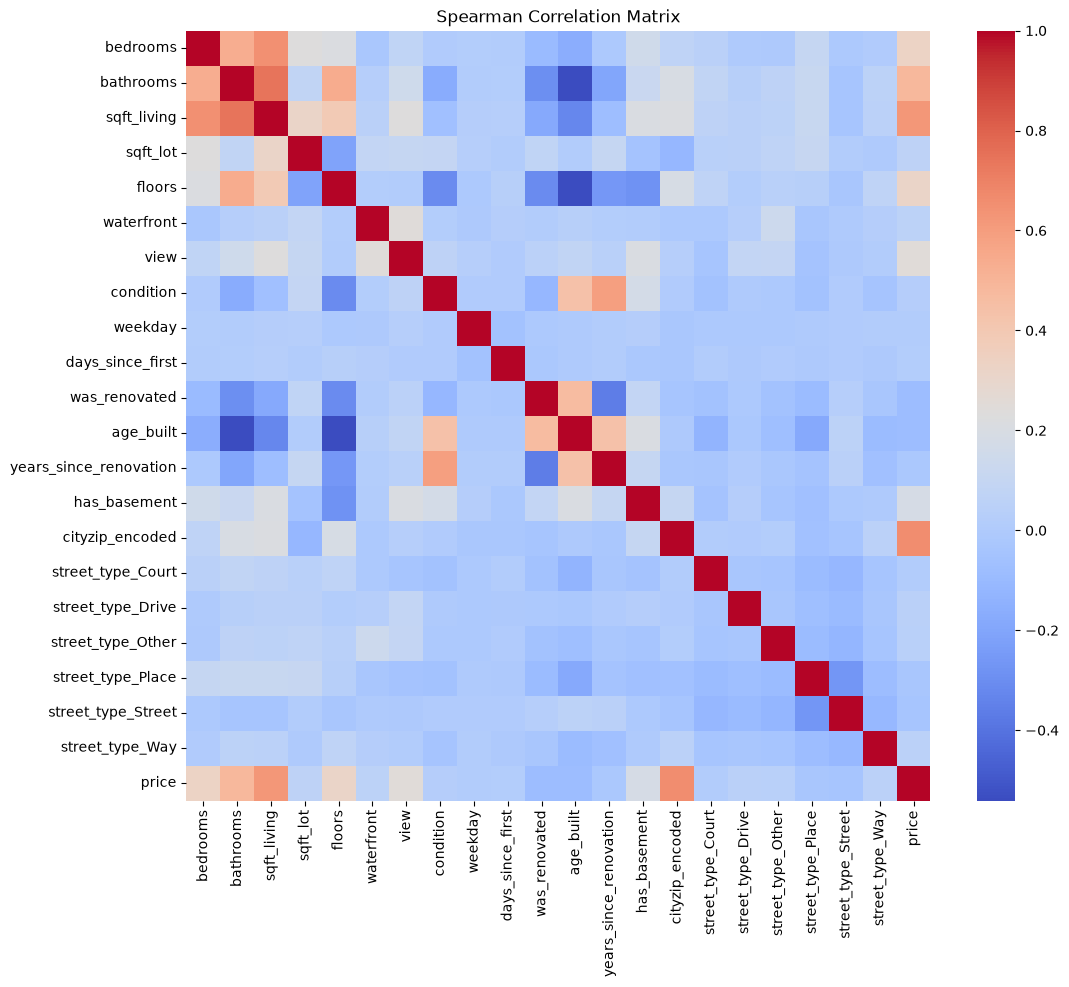

Spearman Correlation Matrix plotted.


In [ ]:
# --- Step 5: Advanced Correlation Analysis ---
print("Calculating Spearman Correlations...")
df_combined = pd.concat([train, val, test], axis=0)
spearman_corr = df_combined.corr(method='spearman')

# We want to see correlation between features and the target (log price)
# Since we don't have the target in X_train, let's calculate correlation between features
# and then visualize the top ones relative to what we expect to be important.

plt.figure(figsize=(12, 10))
sns.heatmap(spearman_corr, annot=False, cmap='coolwarm')
plt.title('Spearman Correlation Matrix')
plt.show()

print("Spearman Correlation Matrix plotted.")

Training XGBoost to extract feature importance...


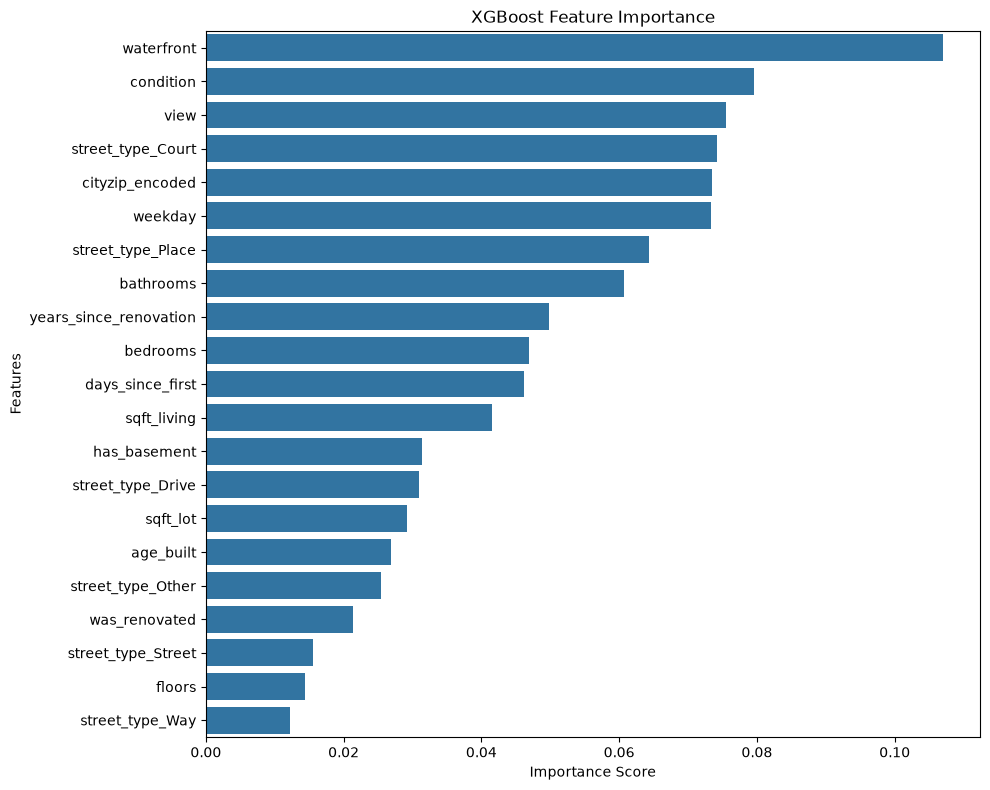

Feature Importance plot displayed.


In [ ]:
# --- Step 6: Model-Based Feature Importance ---
print("Training XGBoost to extract feature importance...")
model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("Feature Importance plot displayed.")

## Summary of Findings

Compare the **Spearman Correlation** matrix with the **XGBoost Feature Importance** plot.

- If a feature has low Spearman correlation but high Importance, it indicates a strong **non-linear relationship**.
- Features like `condition` or `yr_renovated` (via `years_since_renovation`) often show this behavior.
- This confirms that these features *are* doing something significant for the model, even if they don't show up strongly in a linear correlation matrix.